In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
# Load dataset
df = pd.read_csv('../data/SYNAPSE.csv')

# Inspect dataset
print("INSPECT DATASET")
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes.to_string()}")
print(f"\nMissing values:\n{df.isnull().sum().to_string()}")
print("\nFirst 3 rows:")
print(df.head(3).to_string())

print("\nUnique Symptom count:")
print(df['Symptoms'].nunique())

INSPECT DATASET
Shape: (130637, 6)

Data types:
Symptoms                str
Gender                  str
Age                     str
Duration                str
Severity                str
Final Recommendation    str

Missing values:
Symptoms                0
Gender                  0
Age                     0
Duration                0
Severity                0
Final Recommendation    0

First 3 rows:
                                                                                                                                                             Symptoms  Gender            Age             Duration Severity Final Recommendation
0  Unwanted weight loss, Mouth sore, Persistent mouth pain, Lump thickening in lips, mouth, cheek, White red patch on gums, tongue, tonsil, mouth lining, sore throat    Male     6-15 years  Greater than 3 days   Severe  Doctor Consultation
1     Feeling tired, Shortness breath, Blue skin color, gray skin color, Trouble gaining weight, Irritability, Cryin

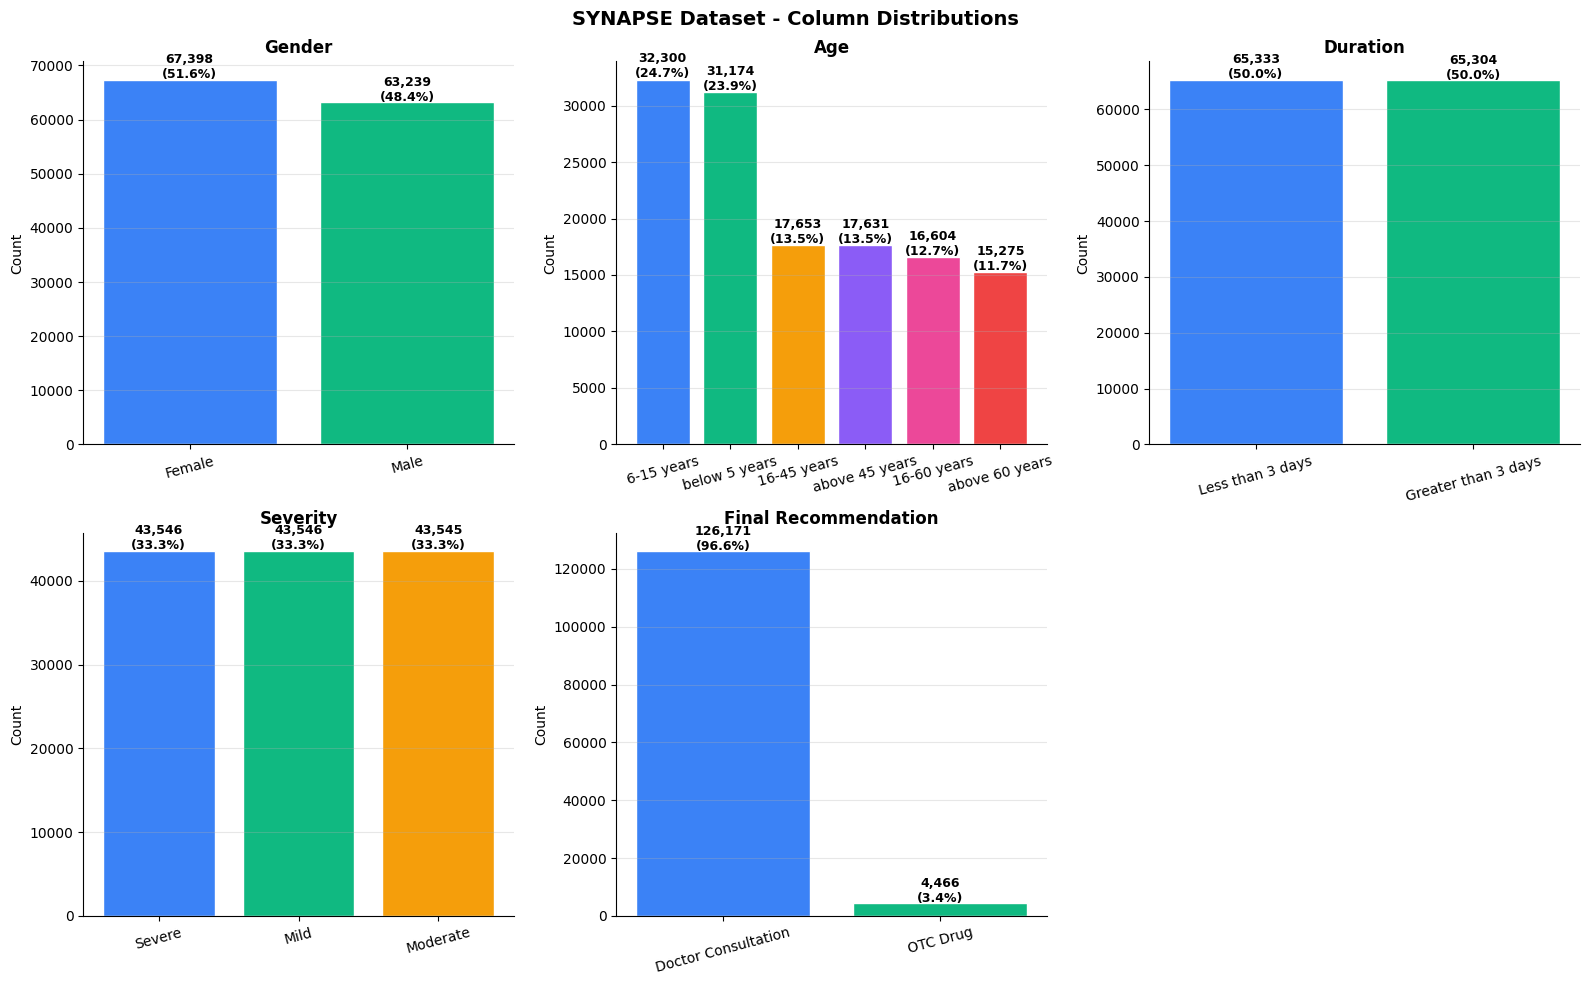

In [24]:
# Visualize dataset columns

cols_to_plot = ['Gender', 'Age', 'Duration', 'Severity', 'Final Recommendation']
bar_colors = ['#3B82F6', '#10B981', '#F59E0B', '#8B5CF6', '#EC4899', '#EF4444', '#06B6D4']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('SYNAPSE Dataset - Column Distributions', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    counts = df[col].value_counts()

    colors = bar_colors[:len(counts)]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white')

    # add count and percentage label on each bar
    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 200,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', fontsize=9, fontweight='bold'
        )

    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# hide the 6th empty subplot
axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('../results/column_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Analyse potential target columns
print("\nFinal Recommendation distribution:")
print(df['Final Recommendation'].value_counts())
print("\nSeverity distribution:")
print(df['Severity'].value_counts())

# Check conflict rates of potential targets
dup_fr = df.groupby(['Symptoms','Age','Duration','Gender'])['Final Recommendation'].nunique()
conflict_rate_fr = (dup_fr > 1).sum() / len(dup_fr) * 100
print(f"\nFinal Recommendation conflict rate: {conflict_rate_fr:.1f}%")

dup_sev = df.groupby(['Symptoms','Age','Duration','Gender'])['Severity'].nunique()
conflict_rate_sev = (dup_sev > 1).sum() / len(dup_sev) * 100
print(f"\nSeverity conflict rate: {conflict_rate_sev:.1f}%")


Final Recommendation distribution:
Final Recommendation
Doctor Consultation    126171
OTC Drug                 4466
Name: count, dtype: int64

Severity distribution:
Severity
Severe      43546
Mild        43546
Moderate    43545
Name: count, dtype: int64

Final Recommendation conflict rate: 7.2%

Severity conflict rate: 99.5%


In [ ]:
# Clean
df.columns = df.columns.str.strip().str.replace(' ', '_')
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()
df['symptoms_clean'] = df['Symptoms'].str.lower().str.strip()